In [44]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [45]:
df=pd.read_csv("C:\\Users\\axay1\\Downloads\\fitness_steps_calories.csv")
df

,Daily_Steps,Calories_Burned
0,17795,694
1,2860,127
2,7390,309
3,13964,560
4,13284,464
...,...,...
995,15221,537
996,3279,102
997,15192,541
998,9083,351


# DATA K ROWS AND COLUMN JAAN NA 

In [46]:
df.shape

(1000, 2)

# DATA K INFORMATION KO JAAN NA 

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Daily_Steps      1000 non-null   int64
 1   Calories_Burned  1000 non-null   int64
dtypes: int64(2)
memory usage: 15.8 KB


# STRATING KI FIVE ROWS KO UNDERSTAN DKRNA  

In [48]:
df.head()

,Daily_Steps,Calories_Burned
0,17795,694
1,2860,127
2,7390,309
3,13964,560
4,13284,464


# LAST KI FIVE ROWS UNDERSTAND KRNA 

In [49]:
df.tail()

,Daily_Steps,Calories_Burned
995,15221,537
996,3279,102
997,15192,541
998,9083,351
999,13093,473


# DATA KO DESCRIBE KARNA 

In [50]:
df.describe()

,Daily_Steps,Calories_Burned
count,1000.000000,1000.000000
mean,10806.042000,434.403000
std,5067.763359,209.427645
min,2009.000000,23.000000
25%,6657.000000,260.000000
50%,10515.500000,427.500000
75%,15132.750000,604.000000
max,19988.000000,921.000000


# NULL VALUES KO CHECK KRNA 

In [51]:
df.isnull().sum()

Daily_Steps        0
Calories_Burned    0
dtype: int64

# CHOTI VALUES KO UPER AND BADI VALUES KO NICHE SIFHT KARNA 

In [52]:
df=df.sort_values(by="Daily_Steps")
df


,Daily_Steps,Calories_Burned
543,2009,30
762,2009,157
661,2055,108
792,2077,82
736,2117,54
...,...,...
26,19912,751
469,19924,862
992,19939,840
415,19955,832


# INPUT OR OUTPUT KO X,Y VARIABLE ME DAAL NA 


In [53]:
x  =df[["Daily_Steps"]]
x



,Daily_Steps
543,2009
762,2009
661,2055
792,2077
736,2117
...,...
26,19912
469,19924
992,19939
415,19955


In [54]:
y= df["Calories_Burned"]
y

543     30
762    157
661    108
792     82
736     54
      ... 
26     751
469    862
992    840
415    832
776    785
Name: Calories_Burned, Length: 1000, dtype: int64

# TRAIN OT TEST ME SPLIT KRNA DATA KO 

In [55]:
x_train, x_test, y_train, y_test = train_test_split(x,y,  test_size = 0.2
                                                   , random_state= 42)
x_train

,Daily_Steps
262,2699
371,11207
297,14039
348,11662
435,16512
...,...
173,3986
612,6892
202,17151
526,9483


# LINEAR REGRESSION MODEL IMPORT KRNA 

In [56]:
from sklearn.linear_model import LinearRegression

In [57]:
model = LinearRegression()
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# MODEL SE PREDICT KARNWANA 

In [58]:
y_pred =model.predict(x_test)

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("R2 Score:", r2_score(y_test, y_pred) * 100)


R2 Score: 94.55032075694649


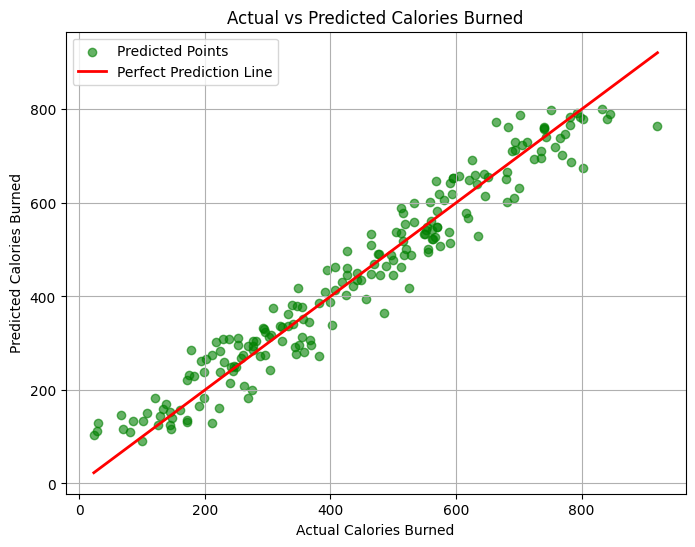

In [60]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred,
            color="green", alpha=0.6, label="Predicted Points")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect Prediction Line")

plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("Actual vs Predicted Calories Burned")
plt.legend()
plt.grid(True)

plt.show()


# RIDGE MODEL LAGANA 

In [20]:
from sklearn.linear_model import Ridge

In [21]:
ridge = Ridge()
ridge.fit(x_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [22]:
pre = ridge.predict(x_test)
print("R2 Score:", r2_score(y_test, pre) * 100)

R2 Score: 94.5503207567726


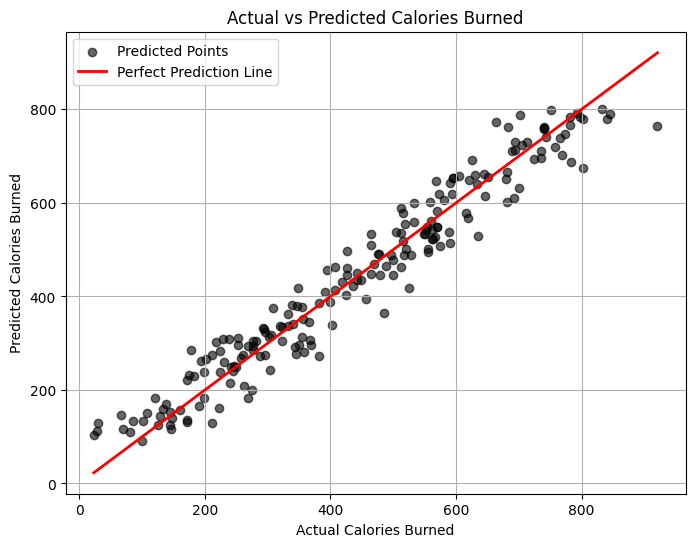

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pre,
            color="black", alpha=0.6, label="Predicted Points")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect Prediction Line")

plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("Actual vs Predicted Calories Burned")
plt.legend()
plt.grid(True)

plt.show()


#  LASSO MODEL


In [24]:
from sklearn.linear_model import Lasso


In [25]:
lasso = Lasso()
lasso.fit(x_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [26]:
pred  = lasso.predict(x_test)

In [27]:
print("R2 Score:", r2_score(y_test, pred) * 100)

R2 Score: 94.55031727353114


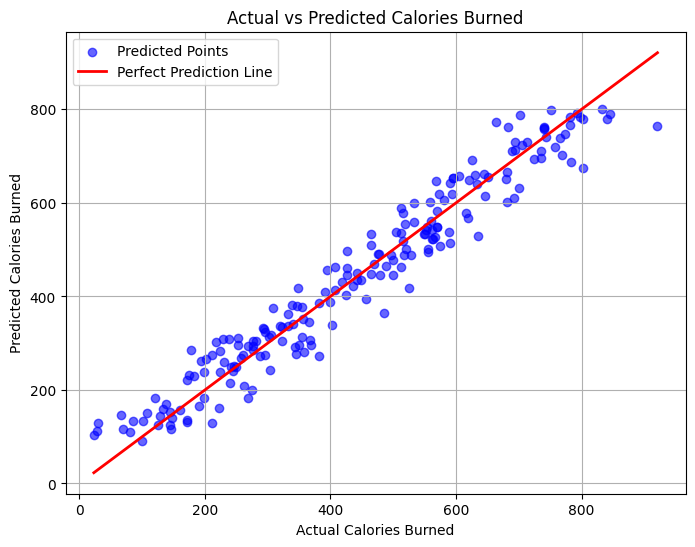

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred,
            color="blue", alpha=0.6, label="Predicted Points")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect Prediction Line")

plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("Actual vs Predicted Calories Burned")
plt.legend()
plt.grid(True)

plt.show()


In [29]:
from sklearn.linear_model import ElasticNet


In [30]:
elasticnet = ElasticNet()
elasticnet.fit(x_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


# ELASTICNET MODEL

In [31]:
epre =  elasticnet.predict(x_test)


In [32]:
print("R2 Score:", r2_score(y_test, epre) * 100)

R2 Score: 94.55031894570475


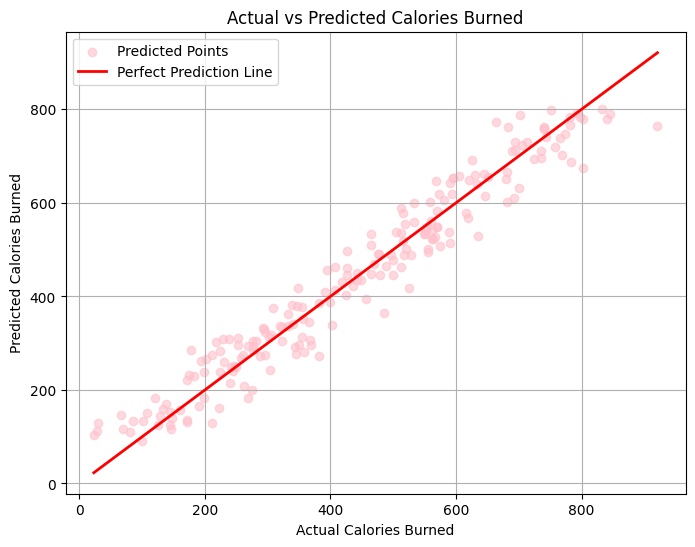

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, epre,
            color="pink", alpha=0.6, label="Predicted Points")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linewidth=2, label="Perfect Prediction Line")

plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("Actual vs Predicted Calories Burned")
plt.legend()
plt.grid(True)

plt.show()


In [34]:
x

,Daily_Steps
543,2009
762,2009
661,2055
792,2077
736,2117
...,...
26,19912
469,19924
992,19939
415,19955
